# Machine Learning Homework - Group 30
## Predicting repeat purchases within 90 days

**Goal:** use information available at a purchase to predict `repeat_purchase_90d` (1 = another purchase within 90 days; 0 = no repeat purchase).

Each row is a customer purchase occasion, with current-purchase information and summaries of earlier purchases. Customers can appear in several rows. We follow the four notebook tasks in the homework: explore, clean and prepare, select features, and build/evaluate a classifier. Finally, we generate predictions for every test row.

The approach is deliberately small: one reusable preprocessing pipeline, a majority-class baseline, logistic regression, and a modest random forest. No PDF is created. Predictions are embedded in this notebook, so running it creates no additional project files.

## 1. Setup and load the data
Keep this notebook beside the `data` folder. It uses pandas, NumPy, matplotlib, seaborn, and scikit-learn. If packages are missing, uncomment the installation line below and restart the kernel afterward. A fixed random seed makes the model results reproducible within the same package versions.

In [5]:
# %pip install pandas numpy matplotlib seaborn scikit-learn
from pathlib import Path
import base64
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, HTML

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

SEED = 30
TARGET = 'repeat_purchase_90d'
DATA_DIR = Path('data')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 12)
print(f'Python {platform.python_version()} | pandas {pd.__version__} | '
      f'NumPy {np.__version__} | scikit-learn {sklearn.__version__}')

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
customers = pd.read_csv(DATA_DIR / 'clientes.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

display(pd.DataFrame({
    'file': ['train.csv', 'test.csv', 'clientes.csv', 'sample_submission.csv'],
    'rows': [len(train), len(test), len(customers), len(sample_submission)],
    'columns': [train.shape[1], test.shape[1], customers.shape[1], sample_submission.shape[1]],
}))
display(train.head())
assert train[TARGET].notna().all() and set(train[TARGET].unique()) == {0, 1}
assert TARGET not in test.columns
assert set(train.columns) - {TARGET} == set(test.columns)
assert train['ID'].is_unique and test['ID'].is_unique
assert set(train['ID']).isdisjoint(test['ID'])

Python 3.13.15 | pandas 3.0.6 | NumPy 2.5.3 | scikit-learn 1.9.1


,file,rows,columns
0,train.csv,6534,39
1,test.csv,986,38
2,clientes.csv,1143,13
3,sample_submission.csv,986,2


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,...,transport_method,warehouse,document_series,purchase_date,ID,random_noise
0,558.11,510.90,453.75,104.36,0.0,0.0,...,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,10000000,-0.660448
1,978.80,830.02,795.77,183.03,0.0,0.0,...,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,10000001,0.924510
2,10.33,12.00,8.40,1.93,0.0,0.0,...,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,10000002,-0.258730
3,856.83,696.61,696.61,160.22,0.0,0.0,...,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,10000003,1.448402
4,1616.10,1488.85,1313.90,302.20,0.0,0.0,...,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,10000004,-1.058890


### What do the columns describe?

| Group | Examples | Meaning |
|---|---|---|
| Current purchase | `Total a Pagar`, `Custo`, `N_ Detalhes` | Amount payable, cost, and number of line items |
| Earlier purchases | `prior_purchase_count`, `prior_total_spend` | Customer history before the current purchase |
| Recent activity | `purchase_count_90d`, `spend_365d` | Purchase counts and spending in earlier time windows |
| Timing | `days_since_previous_purchase`, `customer_tenure_days`, `purchase_date` | Recency, tenure, and purchase date |
| Categories | `payment_type`, `salesperson`, `transport_method` | Operational categories with anonymized labels |
| Identifiers | `ID`, `customer_id` | Row identifier and customer join key |
| Target | `repeat_purchase_90d` | Whether the customer purchases again within 90 days |

The meanings of the Portuguese amount columns are inferred from their names; there is no detailed data dictionary in the homework. Historical features are assumed to contain only information available at the purchase date. We do not reconstruct history from future rows.

In [6]:
quality = pd.DataFrame({
    'type': train.dtypes.astype(str),
    'missing': train.isna().sum(),
    'missing_%': train.isna().mean().mul(100).round(1),
    'unique_values': train.nunique(),
})
display(quality)
display(train.describe().T.round(2))
display(train.select_dtypes(exclude='number').describe().T)

purchase_dates = pd.to_datetime(train['purchase_date'], errors='coerce')
test_dates = pd.to_datetime(test['purchase_date'], errors='coerce')
feature_columns = train.columns.difference(['ID', 'customer_id', TARGET])
print('Exact duplicate rows:', train.duplicated().sum())
print('Duplicate customer/date pairs with a known date:',
      train.loc[purchase_dates.notna()].duplicated(['customer_id', 'purchase_date']).sum())
print('Rows with every purchase feature missing:', train[feature_columns].isna().all(axis=1).sum())
print('Invalid nonempty dates:', (train['purchase_date'].notna() & purchase_dates.isna()).sum())
print('Training date range:', purchase_dates.min().date(), 'to', purchase_dates.max().date())
print('Test date range:', test_dates.min().date(), 'to', test_dates.max().date())
print('Distinct training customers:', train['customer_id'].nunique())
print('Test rows belonging to customers absent from training:',
      (~test['customer_id'].isin(train['customer_id'])).sum())

,type,missing,missing_%,unique_values
Total a Pagar,float64,65,1.0,6122
Total Bruto,float64,65,1.0,6038
Total Liquido,float64,65,1.0,6093
Total Imp_,float64,65,1.0,5406
Total Portes,float64,65,1.0,215
Total Desc_ Global,float64,65,1.0,109
Total Desc_ Linha,float64,65,1.0,3519
Custo,float64,65,1.0,5736
N_ Detalhes,float64,65,1.0,171
invoice_count_current_purchase,float64,65,1.0,5


,count,mean,std,min,25%,50%,75%,max
Total a Pagar,6469.0,925.56,1335.00,0.93,188.92,476.74,1087.67,2.229721e+04
Total Bruto,6469.0,886.15,1327.64,0.83,175.74,445.74,1036.70,2.157828e+04
Total Liquido,6469.0,773.34,1136.36,0.76,154.38,389.91,903.37,1.812781e+04
Total Imp_,6469.0,152.22,225.26,0.00,29.93,79.74,184.84,4.169400e+03
Total Portes,6469.0,1.15,5.84,0.00,0.00,0.00,0.00,1.810600e+02
Total Desc_ Global,6469.0,0.35,5.12,0.00,0.00,0.00,0.00,2.184900e+02
Total Desc_ Linha,6469.0,112.47,289.99,0.00,0.00,13.13,92.28,4.103440e+03
Custo,6469.0,328.17,519.51,0.00,49.05,152.54,396.06,7.427400e+03
N_ Detalhes,6469.0,21.52,27.71,1.00,4.00,11.00,29.00,4.230000e+02
invoice_count_current_purchase,6469.0,1.07,0.31,1.00,1.00,1.00,1.00,5.000000e+00


,count,unique,top,freq
payment_type,6274,9,Maybe Tomorrow Payment 7,4565
salesperson,6275,9,VLOOKUP Master 1,4054
commercial_zone,6469,5,Decorative Dashboard Zone 4,6260
transport_method,6273,80,Maybe Tomorrow Delivery 72,1119
warehouse,6274,2,Final Excel Warehouse 1,6253
document_series,6469,3,Ctrl Z Series 2,2738
purchase_date,6469,1492,2015-10-31,52


Exact duplicate rows: 0
Duplicate customer/date pairs with a known date: 0
Rows with every purchase feature missing: 65
Invalid nonempty dates: 0
Training date range: 2015-07-11 to 2025-02-15
Test date range: 2025-05-24 to 2026-10-06
Distinct training customers: 610
Test rows belonging to customers absent from training: 54


In [7]:
nonnegative_columns = train.select_dtypes('number').columns.difference(
    ['ID', 'customer_id', TARGET, 'random_noise']
).tolist()
expected_mean = train['prior_total_spend'].div(train['prior_purchase_count'].replace(0, np.nan))
anomaly_counts = pd.Series({
    'Negative days since previous purchase': (train['days_since_previous_purchase'] < 0).sum(),
    'Negative average purchase gap': (train['prior_mean_gap_days'] < 0).sum(),
    'Negative prior mean purchase value': (train['prior_mean_purchase_value'] < 0).sum(),
    'Negative 365-day spend': (train['spend_365d'] < 0).sum(),
    'Prior mean inconsistent with total / count':
        ((train['prior_mean_purchase_value'] - expected_mean).abs() > 0.01).sum(),
    '365-day spend above all previous spend':
        (train['spend_365d'] > train['prior_total_spend'] + 0.01).sum(),
    '365-day spend below 180-day spend':
        (train['spend_365d'] + 0.01 < train['spend_180d']).sum(),
})
display(anomaly_counts.to_frame('rows'))

customer_quality = pd.DataFrame({
    'missing_%': customers.isna().mean().mul(100).round(1),
    'unique_values': customers.nunique(),
})
display(customer_quality)
assert customers['customer_id'].is_unique
print('Training rows without a customer-table match:',
      (~train['customer_id'].isin(customers['customer_id'])).sum())

,rows
Negative days since previous purchase,16
Negative average purchase gap,16
Negative prior mean purchase value,16
Negative 365-day spend,15
Prior mean inconsistent with total / count,78
365-day spend above all previous spend,54
365-day spend below 180-day spend,15


,missing_%,unique_values
customer_id,0.0,1143
country_or_region,0.0,11
commercial_region,10.0,37
island,50.6,10
municipality,13.9,183
city,47.8,417
postal_area,6.2,271
postal_code,14.9,828
street,52.3,511
address,0.5,1120


Training rows without a customer-table match: 0


### Data-quality findings and the customer table
There are **6,534 training rows**, **986 test rows**, and **1,143 customer records**. The target has no missing values. IDs are unique, and there are no exact duplicate rows or duplicate customer/date pairs when the date is known. However, 65 rows have all purchase features missing, including the date.

Some missing history is natural: a first-time customer has no previous-purchase interval, and a standard deviation needs enough earlier observations. Other missingness and corruptions also occur: negative time gaps, negative spending, and values of one billion. We should not treat missing history as an observed zero or delete every customer with incomplete history.

`clientes.csv` has a unique join key, and every training row can be matched. We **do not join it for this compact model**: address, company, and postal fields mostly identify individual customers; several geographic fields are sparse; `customer_type` is entirely empty; and tenure already summarizes customer history. Broader geographic fields could be tested later, but we make no claim that they have no predictive value. An eventual join would need `validate='many_to_one'` to avoid multiplying rows.

## 2. Prepare the data and define an honest assessment
### Simple, reproducible cleaning
The following function applies the same row-level rules to training and test data. It learns no medians, category frequencies, or target statistics.

- Convert impossible negative amounts, counts, and durations to missing values.
- Recalculate `prior_mean_purchase_value` from prior total spending divided by prior purchase count when these inputs are available. This repairs missing or corrupted averages using information from the same row. Otherwise, reject averages outside their supplied minimum/maximum.
- Reject 365-day spending above all prior spending or below 180-day spending. There is no reason to retain these internally inconsistent values.
- Keep plausible large purchases. A logarithmic transformation later reduces skew without an arbitrary outlier cutoff.
- Add two easy-to-explain features: whether this is the first purchase, and the proportion of the past year's purchases made in the last 90 days.
- Remove identifiers, `random_noise`, and the raw date from model inputs. The date is used to split the data. IDs remain unchanged in the original tables for the final submission.

Missing values will be filled **inside the fitted pipeline**, not here. This keeps information from later assessment periods out of preprocessing.

In [8]:
def prepare_features(frame):
    x = frame.drop(columns=[TARGET, 'ID', 'customer_id', 'purchase_date', 'random_noise'],
                   errors='ignore').copy()
    numeric = x.select_dtypes('number').columns
    x[numeric] = x[numeric].replace([np.inf, -np.inf], np.nan)
    x[numeric] = x[numeric].mask(x[numeric] < 0)

    count = x['prior_purchase_count']
    valid_history = count.gt(0) & x['prior_total_spend'].notna()
    x.loc[valid_history, 'prior_mean_purchase_value'] = (
        x.loc[valid_history, 'prior_total_spend'] / count.loc[valid_history]
    )
    bad_mean = (
        (x['prior_mean_purchase_value'] + 0.01 < x['prior_min_purchase_value']) |
        (x['prior_mean_purchase_value'] > x['prior_max_purchase_value'] + 0.01)
    )
    x.loc[bad_mean | count.eq(0), 'prior_mean_purchase_value'] = np.nan

    bad_spend = (
        (x['spend_365d'] > x['prior_total_spend'] + 0.01) |
        (x['spend_365d'] + 0.01 < x['spend_180d'])
    )
    x.loc[bad_spend, 'spend_365d'] = np.nan

    x['is_first_purchase'] = count.eq(0).astype(float).where(count.notna())
    yearly_count = x['purchase_count_365d']
    x['recent_purchase_share'] = x['purchase_count_90d'] / yearly_count.replace(0, np.nan)
    x.loc[yearly_count.eq(0) & x['purchase_count_90d'].eq(0), 'recent_purchase_share'] = 0.0

    for col in x.select_dtypes(exclude='number').columns:
        # Normalize blanks and use np.nan for compatibility with sklearn imputers.
        x[col] = x[col].str.strip().replace('', np.nan).astype(object)
        x[col] = x[col].where(x[col].notna(), np.nan)
    return x

X = prepare_features(train)
y = train[TARGET].astype(int)
X_test = prepare_features(test)
assert X.columns.equals(X_test.columns)
assert not X.select_dtypes('number').lt(0).any().any()
assert np.isfinite(X.select_dtypes('number').to_numpy()[X.select_dtypes('number').notna()]).all()
display(pd.DataFrame({
    'raw_missing': train[['prior_mean_purchase_value', 'spend_365d']].isna().sum(),
    'after_cleaning_missing': X[['prior_mean_purchase_value', 'spend_365d']].isna().sum(),
}))

,raw_missing,after_cleaning_missing
prior_mean_purchase_value,862,668
spend_365d,260,329


### Chronological development, validation, and holdout sets
The known training dates run from 2015 to February 2025; test purchases are from May 2025 onward. A chronological assessment therefore resembles the actual prediction task better than a random row split.

1. **Development:** purchases earlier than 90 days before 1 January 2023.
2. **Validation:** purchases during 2023, used to choose between two fixed models.
3. **Final holdout:** purchases from 1 January 2024 onward, used once after choosing the model. Before evaluating it, refit the chosen pipeline on all purchases earlier than 90 days before this holdout starts.

The **90-day gap** lets each fitting row's outcome window finish before the following evaluation period starts. Rows with unknown dates cannot safely enter the chronological assessment; they are included in the final fit on all labeled data. The same customers may appear in earlier and later periods because the task predicts future purchases of both existing and new customers. This is not a test of performance only on unseen customers.

We use **ROC AUC** to choose the model because it measures how well probabilities rank repeat purchasers across thresholds. We also report average precision, accuracy, precision, recall, and F1. Labels use a fixed **0.5 threshold**; no threshold is tuned on the holdout. The PDF does not state the Kaggle scoring metric, so we do not assume one.

In [9]:
validation_start = pd.Timestamp('2023-01-01')
holdout_start = pd.Timestamp('2024-01-01')
horizon = pd.Timedelta(days=90)

fit_mask = purchase_dates < validation_start - horizon
validation_mask = (purchase_dates >= validation_start) & (purchase_dates < holdout_start)
holdout_fit_mask = purchase_dates < holdout_start - horizon
holdout_mask = purchase_dates >= holdout_start

split_masks = {
    'Development fit': fit_mask,
    '2023 validation': validation_mask,
    'Refit before holdout': holdout_fit_mask,
    '2024+ final holdout': holdout_mask,
}
split_summary = []
for name, mask in split_masks.items():
    assert y.loc[mask].nunique() == 2
    split_summary.append({
        'set': name, 'rows': int(mask.sum()),
        'first_date': purchase_dates.loc[mask].min().date(),
        'last_date': purchase_dates.loc[mask].max().date(),
        'repeat_rate': y.loc[mask].mean(),
    })
display(pd.DataFrame(split_summary).set_index('set').round(3))
assert purchase_dates.loc[fit_mask].max() + horizon < purchase_dates.loc[validation_mask].min()
assert purchase_dates.loc[holdout_fit_mask].max() + horizon < purchase_dates.loc[holdout_mask].min()
assert not (holdout_fit_mask & holdout_mask).any()
print('Rows with missing dates, reserved for the final full-data fit:', purchase_dates.isna().sum())

X_fit, y_fit = X.loc[fit_mask], y.loc[fit_mask]
X_val, y_val = X.loc[validation_mask], y.loc[validation_mask]
X_holdout, y_holdout = X.loc[holdout_mask], y.loc[holdout_mask]

,rows,first_date,last_date,repeat_rate
set,,,,
Development fit,4705,2015-07-11,2022-10-02,0.553
2023 validation,767,2023-01-01,2023-12-31,0.581
Refit before holdout,5403,2015-07-11,2023-10-02,0.551
2024+ final holdout,835,2024-01-01,2025-02-15,0.605


Rows with missing dates, reserved for the final full-data fit: 65


### Explore distributions and relationships
The descriptive checks above cover the supplied files. For modeling insights, the following plots and target comparisons use **only the development period**, leaving validation and holdout outcomes out of feature-design decisions.

We inspect class balance, skewed monetary values, recency, and the relationship between recent activity and repeat purchases. The correlation heatmap shows overlapping purchase-history measures; several supplied features describe related behavior.

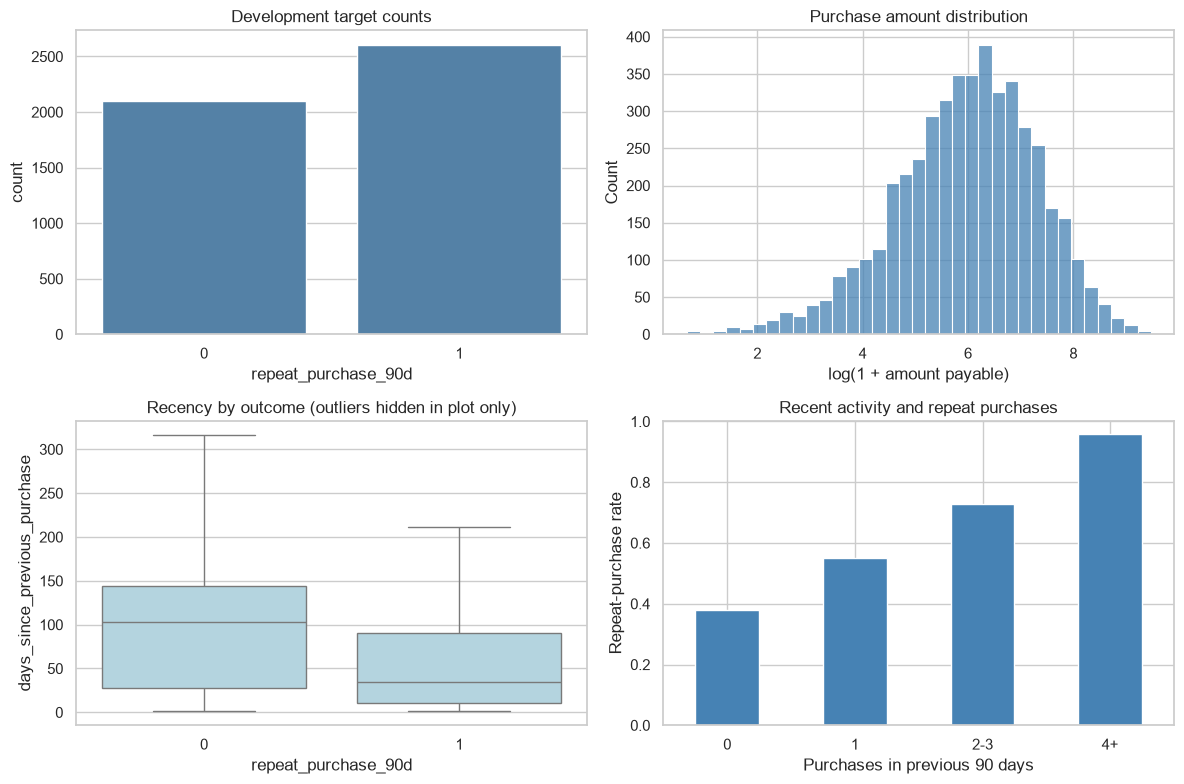

,rows,repeat_rate
purchase_count_90d,,
0,2135,0.380
1,1203,0.551
2-3,780,0.727
4+,587,0.959


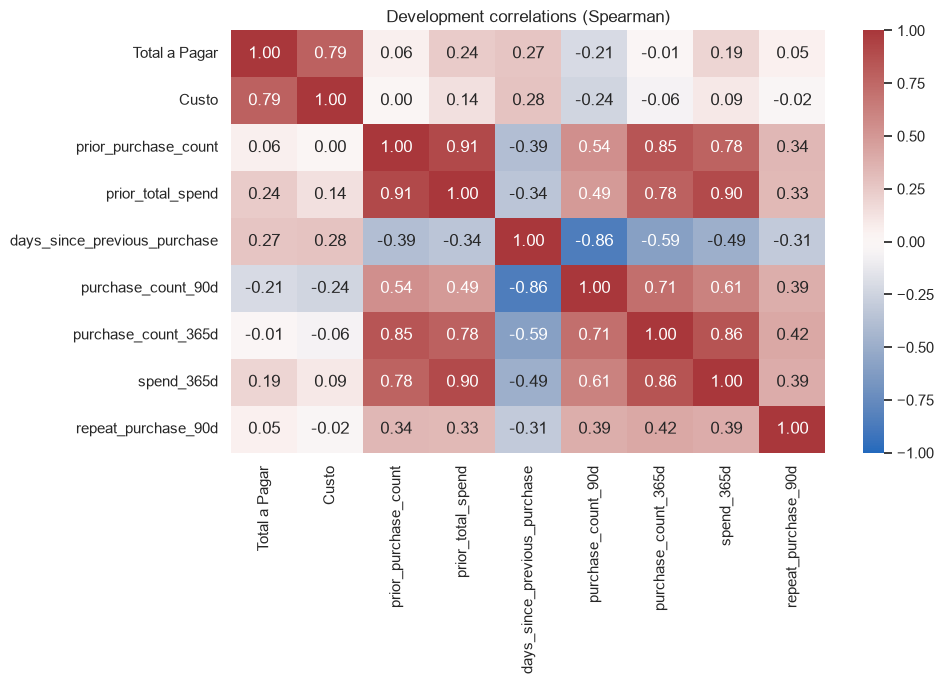

Development repeat-purchase rate: 55.3%


,days_since_previous_purchase,purchase_count_90d,prior_purchase_count,Total a Pagar
repeat_purchase_90d,,,,
0,102.5,0.0,5.0,405.32
1,35.0,1.0,13.0,461.50


,size,mean
payment_type,,
Maybe Tomorrow Payment 7,3375,0.517
Maybe Tomorrow Payment 12,729,0.528
Maybe Tomorrow Payment 9,378,0.960
NaN,133,0.602
Maybe Tomorrow Payment 10,66,0.364
Maybe Tomorrow Payment 8,21,0.286
Maybe Tomorrow Payment 11,2,0.500
Maybe Tomorrow Payment 3,1,1.000


In [10]:
eda = X_fit.copy()
eda[TARGET] = y_fit
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.countplot(data=eda, x=TARGET, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Development target counts')
sns.histplot(np.log1p(eda['Total a Pagar']), bins=35, ax=axes[0, 1], color='steelblue')
axes[0, 1].set(xlabel='log(1 + amount payable)', title='Purchase amount distribution')
sns.boxplot(data=eda, x=TARGET, y='days_since_previous_purchase',
            showfliers=False, ax=axes[1, 0], color='lightblue')
axes[1, 0].set_title('Recency by outcome (outliers hidden in plot only)')
activity = pd.cut(eda['purchase_count_90d'], bins=[-0.1, 0, 1, 3, np.inf],
                  labels=['0', '1', '2-3', '4+'])
activity_summary = eda.groupby(activity, observed=True)[TARGET].agg(['size', 'mean'])
activity_summary['mean'].plot.bar(ax=axes[1, 1], color='steelblue', rot=0)
axes[1, 1].set(xlabel='Purchases in previous 90 days', ylabel='Repeat-purchase rate',
               title='Recent activity and repeat purchases', ylim=(0, 1))
plt.tight_layout()
plt.show()
display(activity_summary.rename(columns={'size': 'rows', 'mean': 'repeat_rate'}).round(3))

correlation_columns = ['Total a Pagar', 'Custo', 'prior_purchase_count', 'prior_total_spend',
                       'days_since_previous_purchase', 'purchase_count_90d',
                       'purchase_count_365d', 'spend_365d', TARGET]
plt.figure(figsize=(10, 7))
sns.heatmap(eda[correlation_columns].corr(method='spearman'), annot=True, fmt='.2f',
            cmap='vlag', vmin=-1, vmax=1, center=0)
plt.title('Development correlations (Spearman)')
plt.tight_layout()
plt.show()

print(f'Development repeat-purchase rate: {y_fit.mean():.1%}')
display(eda.groupby(TARGET)[['days_since_previous_purchase', 'purchase_count_90d',
                            'prior_purchase_count', 'Total a Pagar']].median().round(2))
display(eda.groupby('payment_type', dropna=False)[TARGET].agg(['size', 'mean'])
        .sort_values('size', ascending=False).round(3))

### What the exploration tells us
The development repeat rate is **55.3%**, so class imbalance is modest. Repeat purchasers have a median previous-purchase gap of **35 days**, compared with **102.5 days** for non-repeat purchasers. The repeat rate rises from **38.0%** among customers with no purchases in the preceding 90 days to **95.9%** among customers with at least four. This supports using recent activity and recency as predictors; association is not evidence of causation.

Purchase amounts and historical spending are strongly skewed, so we use `log1p` before fitting the linear model. The correlation plot shows redundancy among purchase counts and spending windows. Payment type also has different observed repeat rates, but very small categories can have extreme rates by chance. We group rare levels rather than treating their observed rates as reliable patterns. We keep the natural class distribution and compare with a majority-class baseline instead of automatically oversampling.

## 3. Preprocessing and feature selection
The pipeline below learns everything from the fitting period:

1. **Numbers:** fill missing values with fitting-set medians and add missing-value indicators; use `log1p` for nonnegative, skewed values; standardize so logistic regression is not dominated by measurement units.
2. **Categories:** fill missing entries with `Missing`, group levels occurring fewer than 20 times, and one-hot encode. Previously unseen levels are handled without failing.
3. **Selection:** remove constant columns, then retain the **20 transformed features with the highest ANOVA F-scores** against the binary target. This is a simple filter selection method. The fixed number 20 keeps the model small; it is not chosen by looking at holdout scores.
4. **Classifier:** fit logistic regression or a random forest. Both receive the same selected inputs for a straightforward comparison. Trees do not require scaling; sharing the preprocessing is convenient, and the monotonic log/scaling transformations preserve numerical ordering.

`ID` and `customer_id` are arbitrary identifiers rather than numerical customer characteristics; `random_noise` has no meaningful predictive role. All three are excluded before statistical selection. ANOVA considers features one at a time, so it may retain correlated features or miss interactions. Logistic regression's L2 regularization helps with redundancy, but this is a simple baseline strategy rather than an exhaustive search.

In [11]:
numeric_features = X_fit.select_dtypes('number').columns.tolist()
categorical_features = X_fit.select_dtypes(exclude='number').columns.tolist()

numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True)),
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encode', OneHotEncoder(handle_unknown='infrequent_if_exist',
                             min_frequency=20, sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('category', categorical_pipeline, categorical_features),
], verbose_feature_names_out=False)

def make_pipeline(classifier):
    return Pipeline([
        ('preprocess', clone(preprocessor)),
        ('remove_constants', VarianceThreshold()),
        ('select', SelectKBest(score_func=f_classif, k=20)),
        ('model', classifier),
    ])

models = {
    'Logistic regression': make_pipeline(LogisticRegression(max_iter=2000, random_state=SEED)),
    'Random forest': make_pipeline(RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=5,
        random_state=SEED, n_jobs=2,
    )),
}
print('Candidate numeric inputs:', len(numeric_features))
print('Candidate categorical inputs:', len(categorical_features))

Candidate numeric inputs: 30
Candidate categorical inputs: 6


## 4. Train models and choose on 2023 validation data
The baseline always predicts the development majority class. Its constant probability gives a ROC AUC of 0.5. The other two models use fixed settings, so no large hyperparameter search is needed. We choose the higher validation ROC AUC (with logistic regression winning an exact tie because it is listed first).

In [12]:
def metric_row(actual, probability, prediction):
    return {
        'ROC AUC': roc_auc_score(actual, probability),
        'Average precision': average_precision_score(actual, probability),
        'Accuracy': accuracy_score(actual, prediction),
        'Precision': precision_score(actual, prediction, zero_division=0),
        'Recall': recall_score(actual, prediction, zero_division=0),
        'F1': f1_score(actual, prediction, zero_division=0),
    }

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(np.zeros((len(y_fit), 1)), y_fit)
validation_results = {
    'Majority baseline': metric_row(
        y_val, baseline.predict_proba(np.zeros((len(y_val), 1)))[:, 1],
        baseline.predict(np.zeros((len(y_val), 1)))),
}
for name, model in models.items():
    model.fit(X_fit, y_fit)
    probability = model.predict_proba(X_val)[:, 1]
    validation_results[name] = metric_row(y_val, probability, (probability >= 0.5).astype(int))

validation_results = pd.DataFrame(validation_results).T
best_name = validation_results.loc[list(models), 'ROC AUC'].idxmax()
display(validation_results.round(3))
print('Chosen model:', best_name)

,ROC AUC,Average precision,Accuracy,Precision,Recall,F1
Majority baseline,0.500,0.581,0.581,0.581,1.000,0.735
Logistic regression,0.784,0.857,0.705,0.763,0.715,0.738
Random forest,0.789,0.858,0.721,0.761,0.758,0.760


Chosen model: Random forest


### Which features were selected?
The table below lists all 20 selected transformed features and their fitting-set F-scores. One-hot categories and missingness flags each count as one transformed feature. These scores measure univariate separation of the two classes, not causal effects or formal significance after selection. We do not calculate feature selection using validation labels.

In [13]:
def selected_feature_table(fitted_pipeline):
    names = fitted_pipeline.named_steps['preprocess'].get_feature_names_out()
    names = names[fitted_pipeline.named_steps['remove_constants'].get_support()]
    selector = fitted_pipeline.named_steps['select']
    return pd.DataFrame({
        'feature': names[selector.get_support()],
        'F_score': selector.scores_[selector.get_support()],
    })

selected_validation_features = selected_feature_table(models[best_name])
display(selected_validation_features.sort_values('F_score', ascending=False).round(2))

,feature,F_score
14,purchase_count_365d,959.06
12,purchase_count_180d,901.27
10,purchase_count_90d,876.18
11,spend_90d,643.74
2,prior_purchase_count,619.74
6,prior_mean_gap_days,619.51
13,spend_180d,518.83
15,spend_365d,461.02
8,purchase_count_30d,422.68
1,days_since_previous_purchase,413.54


### Evaluate once on the final holdout
We now freeze the model choice and refit the entire chosen pipeline on the larger pre-holdout period, retaining the 90-day gap. Medians, category groups, and feature selection are relearned using only that period. The following scores estimate performance on later purchases without using the holdout for model or threshold selection.

A false positive predicts a repeat purchase that does not happen; a false negative misses a customer who does return. Their relative business costs are not specified, so the confusion matrix and both precision and recall are useful alongside ROC AUC.

,ROC AUC,Average precision,Accuracy,Precision,Recall,F1
Majority baseline,0.500,0.605,0.605,0.605,1.000,0.754
Random forest,0.803,0.864,0.732,0.769,0.796,0.782


               precision    recall  f1-score   support

No repeat (0)       0.67      0.63      0.65       330
   Repeat (1)       0.77      0.80      0.78       505

     accuracy                           0.73       835
    macro avg       0.72      0.71      0.72       835
 weighted avg       0.73      0.73      0.73       835



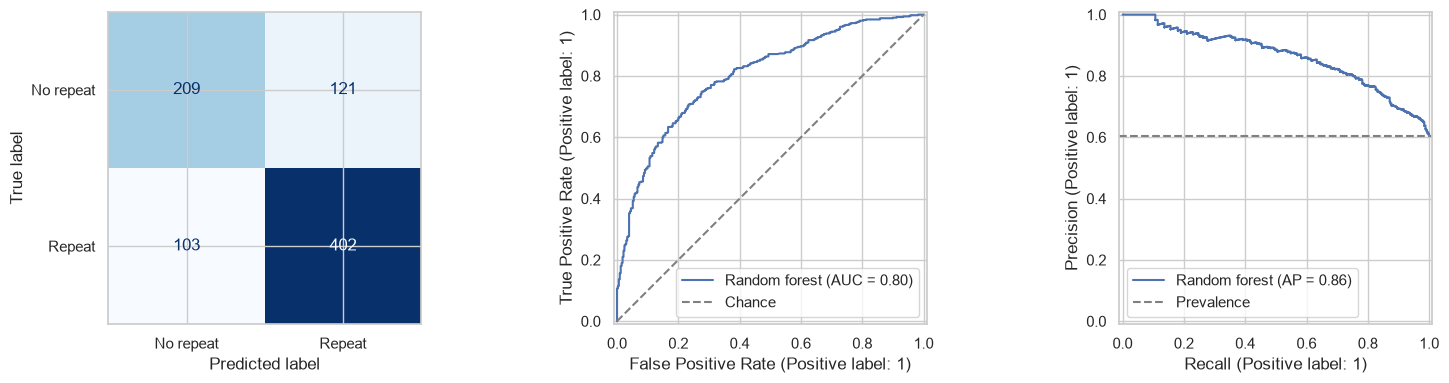

In [14]:
holdout_model = clone(models[best_name])
holdout_model.fit(X.loc[holdout_fit_mask], y.loc[holdout_fit_mask])
holdout_probability = holdout_model.predict_proba(X_holdout)[:, 1]
holdout_prediction = (holdout_probability >= 0.5).astype(int)

holdout_baseline = DummyClassifier(strategy='most_frequent')
holdout_baseline.fit(np.zeros((holdout_fit_mask.sum(), 1)), y.loc[holdout_fit_mask])
holdout_results = pd.DataFrame({
    'Majority baseline': metric_row(
        y_holdout,
        holdout_baseline.predict_proba(np.zeros((len(y_holdout), 1)))[:, 1],
        holdout_baseline.predict(np.zeros((len(y_holdout), 1)))),
    best_name: metric_row(y_holdout, holdout_probability, holdout_prediction),
}).T
display(holdout_results.round(3))
print(classification_report(y_holdout, holdout_prediction,
                            target_names=['No repeat (0)', 'Repeat (1)'], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay.from_predictions(y_holdout, holdout_prediction,
    display_labels=['No repeat', 'Repeat'], cmap='Blues', colorbar=False, ax=axes[0])
RocCurveDisplay.from_predictions(y_holdout, holdout_probability, name=best_name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Chance')
axes[1].legend()
PrecisionRecallDisplay.from_predictions(y_holdout, holdout_probability, name=best_name, ax=axes[2])
axes[2].axhline(y_holdout.mean(), linestyle='--', color='grey', label='Prevalence')
axes[2].legend()
plt.tight_layout()
plt.show()

### Interpret the fitted model
For logistic regression, a positive coefficient increases the predicted probability of a repeat purchase when the other selected inputs stay fixed. For the forest, feature importance summarizes how much each feature contributes to the tree splits. Neither measure proves causation, and correlated inputs can share importance.

,feature,F_score,importance
14,purchase_count_365d,1142.166,0.146
6,prior_mean_gap_days,738.240,0.140
15,spend_365d,529.999,0.094
12,purchase_count_180d,1050.635,0.092
11,spend_90d,757.103,0.070
13,spend_180d,588.488,0.070
10,purchase_count_90d,1018.797,0.059
3,prior_total_spend,426.126,0.053
7,prior_std_gap_days,472.275,0.053
0,Total Desc_ Linha,174.266,0.047


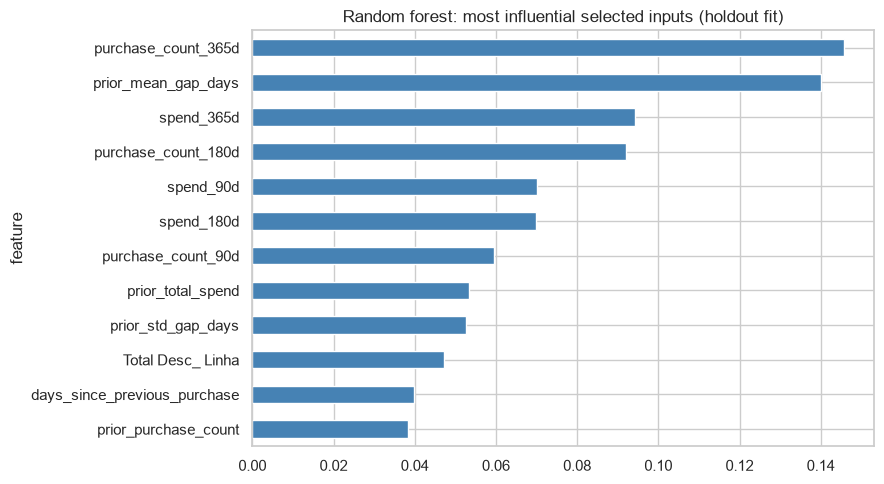

Chosen model: Random forest
Validation ROC AUC: 0.789
Holdout ROC AUC: 0.803
Holdout F1: 0.782
Holdout accuracy: 0.732; baseline accuracy: 0.605


In [15]:
interpretation = selected_feature_table(holdout_model)
classifier = holdout_model.named_steps['model']
if isinstance(classifier, LogisticRegression):
    interpretation['coefficient'] = classifier.coef_[0]
    interpretation = interpretation.sort_values('coefficient', key=abs, ascending=False)
    value_column = 'coefficient'
else:
    interpretation['importance'] = classifier.feature_importances_
    interpretation = interpretation.sort_values('importance', ascending=False)
    value_column = 'importance'
display(interpretation.round(3))
interpretation.head(12).sort_values(value_column).plot.barh(
    x='feature', y=value_column, figsize=(9, 5), legend=False, color='steelblue')
plt.title(f'{best_name}: most influential selected inputs (holdout fit)')
plt.tight_layout()
plt.show()

print(f'Chosen model: {best_name}')
print(f'Validation ROC AUC: {validation_results.loc[best_name, "ROC AUC"]:.3f}')
print(f'Holdout ROC AUC: {holdout_results.loc[best_name, "ROC AUC"]:.3f}')
print(f'Holdout F1: {holdout_results.loc[best_name, "F1"]:.3f}')
print(f'Holdout accuracy: {holdout_results.loc[best_name, "Accuracy"]:.3f}; '
      f'baseline accuracy: {holdout_results.loc["Majority baseline", "Accuracy"]:.3f}')

## 5. Fit on all labeled data and generate test predictions
After assessment, fit a fresh copy of the chosen pipeline on **all of `train.csv`**, including the 65 rows with unknown dates. Including those rows now does not affect the already reported holdout scores. Their missing purchase information limits their usefulness, but imputation lets us retain their observed labels.

All preprocessing and selection are fitted again on training data only. `test.csv` is only transformed and predicted. The exact final selected columns can change as more labeled data becomes available; the selection rule and model settings stay fixed. The full final feature set is printed below.

The sample submission uses binary values, so the submission uses **0/1 predictions** at the fixed 0.5 threshold. The sample's target values are placeholders, not test labels, and are never used for training or evaluation. Test probabilities remain available separately if a competition later specifies a probability-based submission.

In [16]:
final_model = clone(models[best_name])
final_model.fit(X, y)
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)

final_features = selected_feature_table(final_model).sort_values('F_score', ascending=False)
print('Final model:', best_name)
print('Final training rows:', len(X))
display(final_features.round(2))

prediction_by_id = pd.Series(test_prediction, index=test['ID'])
assert sample_submission['ID'].is_unique
assert set(sample_submission['ID']) == set(test['ID'])
submission = sample_submission[['ID']].copy()
submission[TARGET] = submission['ID'].map(prediction_by_id).astype(int)

assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(test)
assert submission['ID'].equals(sample_submission['ID'])
assert not submission.isna().any().any()
assert set(submission[TARGET].unique()).issubset({0, 1})
assert np.isfinite(test_probability).all()
assert ((test_probability >= 0) & (test_probability <= 1)).all()

print(f'Generated {len(submission):,} predictions, one per test observation.')
print(f'Predicted repeat-purchase rate: {submission[TARGET].mean():.1%}')
display(submission.head(10))
display(submission[TARGET].value_counts().rename_axis('predicted_class').to_frame('rows'))

# Embed the complete CSV in the notebook output; do not create another file.
csv_bytes = submission.to_csv(index=False).encode('utf-8')
csv_encoded = base64.b64encode(csv_bytes).decode('ascii')
display(HTML(
    f'<a download="Homework_Group30_submission.csv" '
    f'href="data:text/csv;base64,{csv_encoded}">Download all test predictions as CSV</a>'
))
# Optional later export if your notebook viewer disables embedded download links:
# submission.to_csv('Homework_Group30_submission.csv', index=False)

Final model: Random forest
Final training rows: 6534


,feature,F_score
14,purchase_count_365d,1414.42
12,purchase_count_180d,1277.62
10,purchase_count_90d,1202.37
11,spend_90d,902.20
6,prior_mean_gap_days,893.25
2,prior_purchase_count,877.58
13,spend_180d,718.45
15,spend_365d,651.35
1,days_since_previous_purchase,574.24
8,purchase_count_30d,542.52


Generated 986 predictions, one per test observation.
Predicted repeat-purchase rate: 67.2%


,ID,repeat_purchase_90d
0,10000006,1
1,10000008,1
2,10000010,1
3,10000020,0
4,10000025,1
5,10000035,1
6,10000044,0
7,10000046,0
8,10000049,1
9,10000050,1


,rows
predicted_class,
1,663
0,323


## 6. Conclusions and limitations
**The random forest was selected:** its 2023 validation ROC AUC was **0.789**, compared with **0.784** for logistic regression. This difference is small; we do not claim statistical superiority. On the 835-row final chronological holdout, the forest achieved **0.803 ROC AUC**, **0.864 average precision**, **73.2% accuracy**, and **0.782 F1**. The majority baseline achieved **60.5% accuracy** and **0.754 F1**. The improvement in F1 is therefore more modest than the improvement in accuracy. Forest precision was **76.9%** and recall was **79.6%** at the fixed 0.5 threshold.

The strongest forest inputs were the number of purchases in the previous year, the average historical purchase gap, and yearly spending. This is consistent with the exploration: customers who buy frequently are more likely to return soon. The final 20-feature table above mainly contains purchase-frequency, recency, and spending measures, plus two missingness flags and two operational categories. The two engineered features were candidates but were **not retained** by the fixed selection rule.

The final pipeline was fitted on all **6,534 labeled rows** and generated **986 test predictions**: **663 repeat purchasers** and **323 non-repeat purchasers**. The complete predictions are embedded in the preceding download link. The notebook creates no separate CSV or PDF by default.

The holdout covers one later time period, so its score is not a guarantee for 2025-2026. Customers contribute repeated observations, and unknown-date rows are absent from assessment; these facts limit how broadly the scores can be generalized. Some test customers have no training rows. We also assume that the supplied labels have complete 90-day follow-up and that historical summaries are constructed without future information; the supplied files do not independently establish this. The Kaggle metric and test labels are unavailable, so no competition score is claimed.

Possible next steps would be rolling chronological validation, checking whether broad customer geography improves performance, and choosing a decision threshold using validation data if the costs of errors become known. These are extensions, not changes made after inspecting the holdout.